# Task 1.3 — Feature Hierarchies and Representation Evolution

In this notebook, we analyze how visual representations transform across network depth in ResNet-152:
1. Register PyTorch forward hooks across early, mid, and deep layer stages (`layer1`, `layer2`, `layer3`, `layer4`, `avgpool`).
2. Extract feature activation matrices for validation set samples.
3. Generate individual **t-SNE feature visualizations** for each layer depth stage (`t-SNE visualization of {layer} features`).
4. Visualize multi-panel t-SNE and UMAP feature evolution grids and compute the **Cross-Layer Cosine Similarity Matrix**.

In [1]:
import torch
import numpy as np
from task1_resnet152.src.data import get_cifar10_loaders
from task1_resnet152.src.model import load_resnet152, replace_head
from task1_resnet152.src.hooks import extract_layer_activations
from task1_resnet152.src.visualize import (
    plot_layer_tsne_individual,
    plot_multi_layer_projections,
    plot_layer_similarity_matrix
)

# Select device (CUDA GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

_, val_loader = get_cifar10_loaders(batch_size=256)

model = load_resnet152(pretrained=True)
model = replace_head(model, num_classes=10)
model.to(device)

layer_names = ['layer1', 'layer2', 'layer3', 'layer4', 'avgpool']
activations, labels = extract_layer_activations(model, val_loader, layer_names, num_samples=1000, device=device)

# Flatten spatial feature dimensions for dimensionality reduction
flat_activations = {k: v.numpy() for k, v in activations.items()}
labels_np = labels.cpu().numpy()

c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Files already downloaded and verified
Files already downloaded and verified


### Individual Layer Stage t-SNE Visualizations
Below we plot single-layer t-SNE scatter plots for each depth stage (`layer1`, `layer2`, `layer3`, `layer4`, `avgpool`) with discrete class legends.

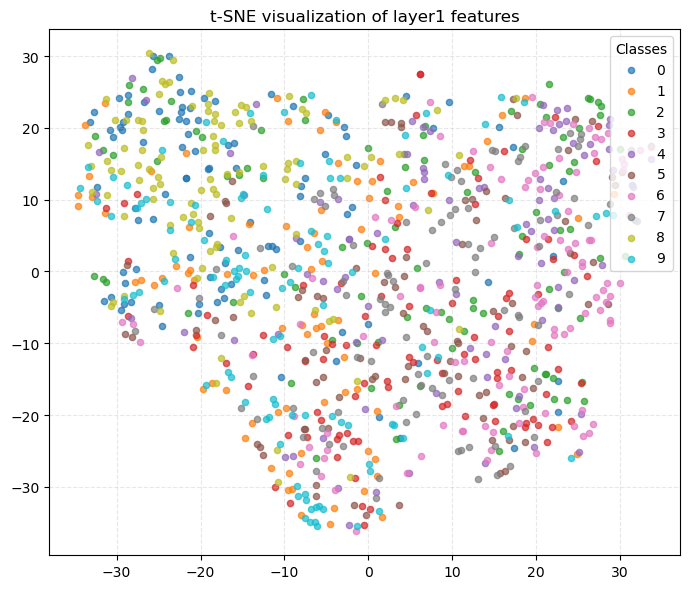

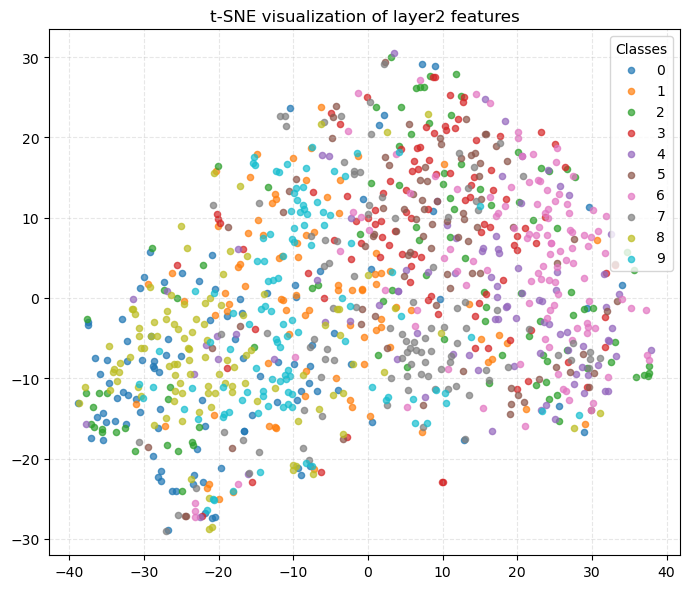

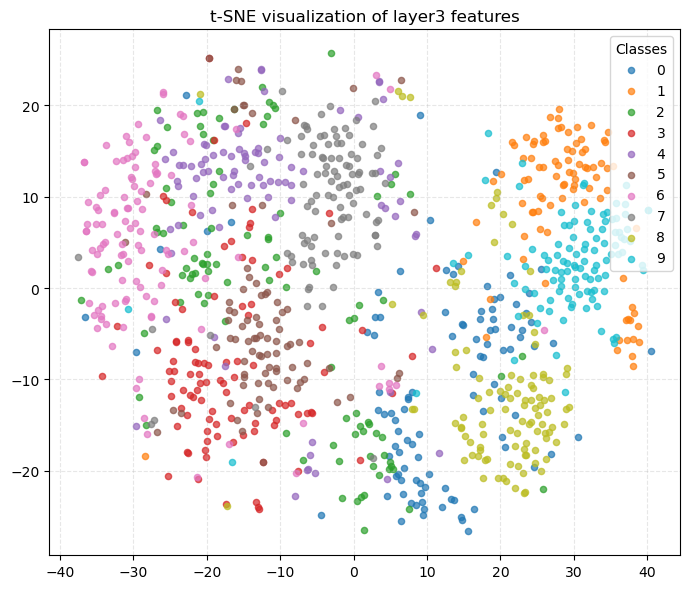

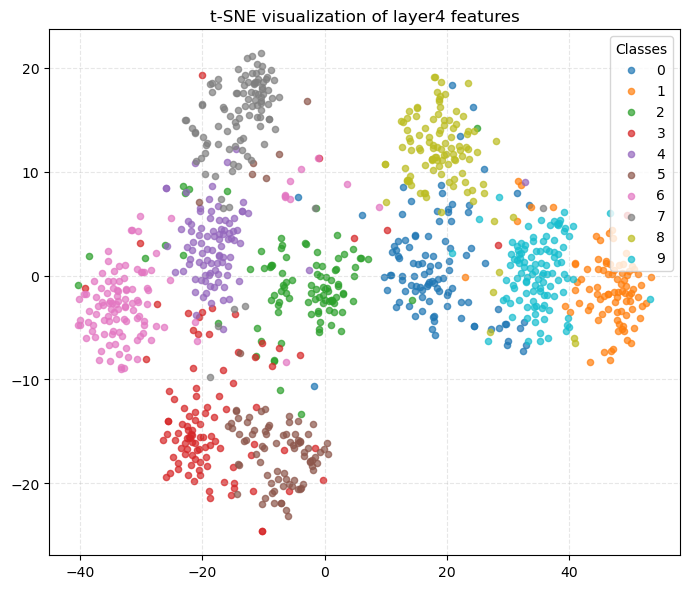

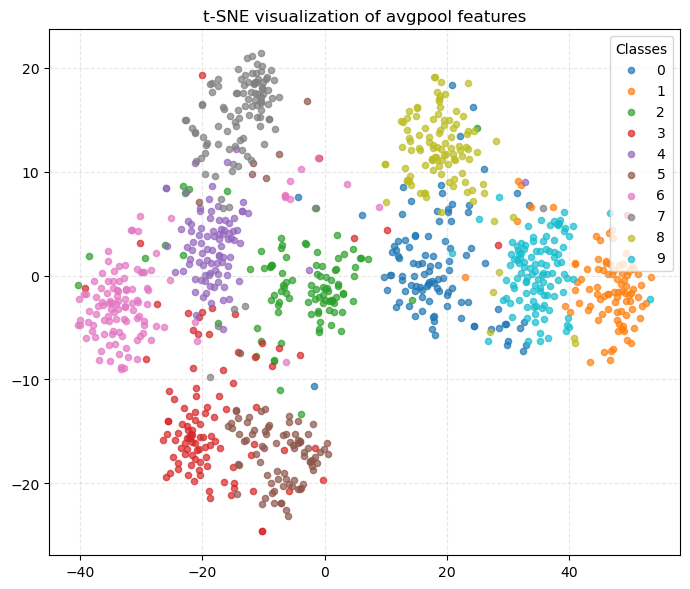

In [2]:
for layer_name in layer_names:
    plot_layer_tsne_individual(
        flat_activations[layer_name],
        labels_np,
        layer_name=layer_name,
        save_path=f'../results/figures/tsne_{layer_name}.png'
    )

### Multi-Layer Feature Manifold Projections (t-SNE & UMAP Grids)
We plot side-by-side 2D t-SNE and UMAP projections across layer depth to observe overall feature cluster progression.

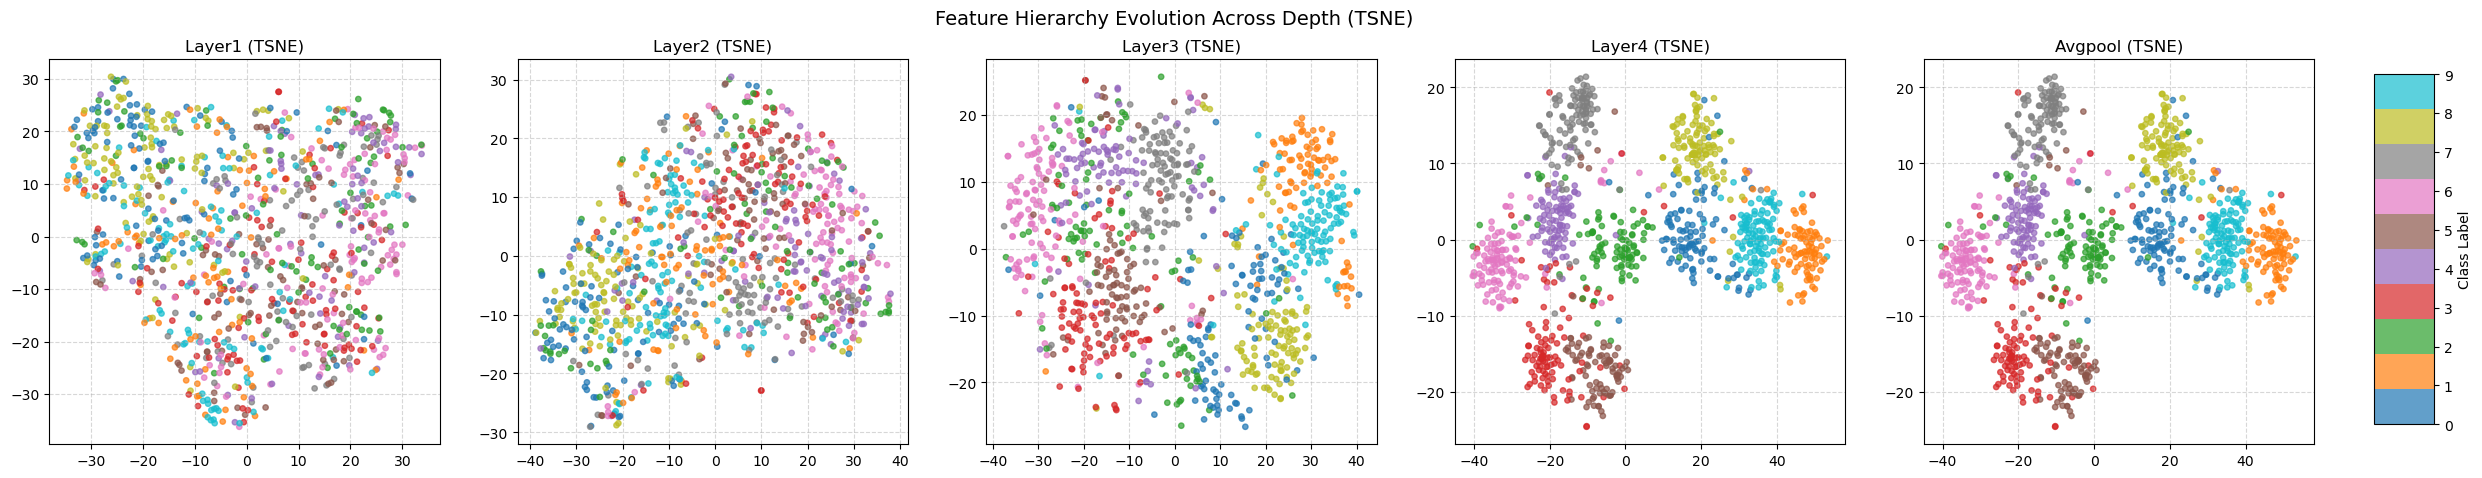

c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


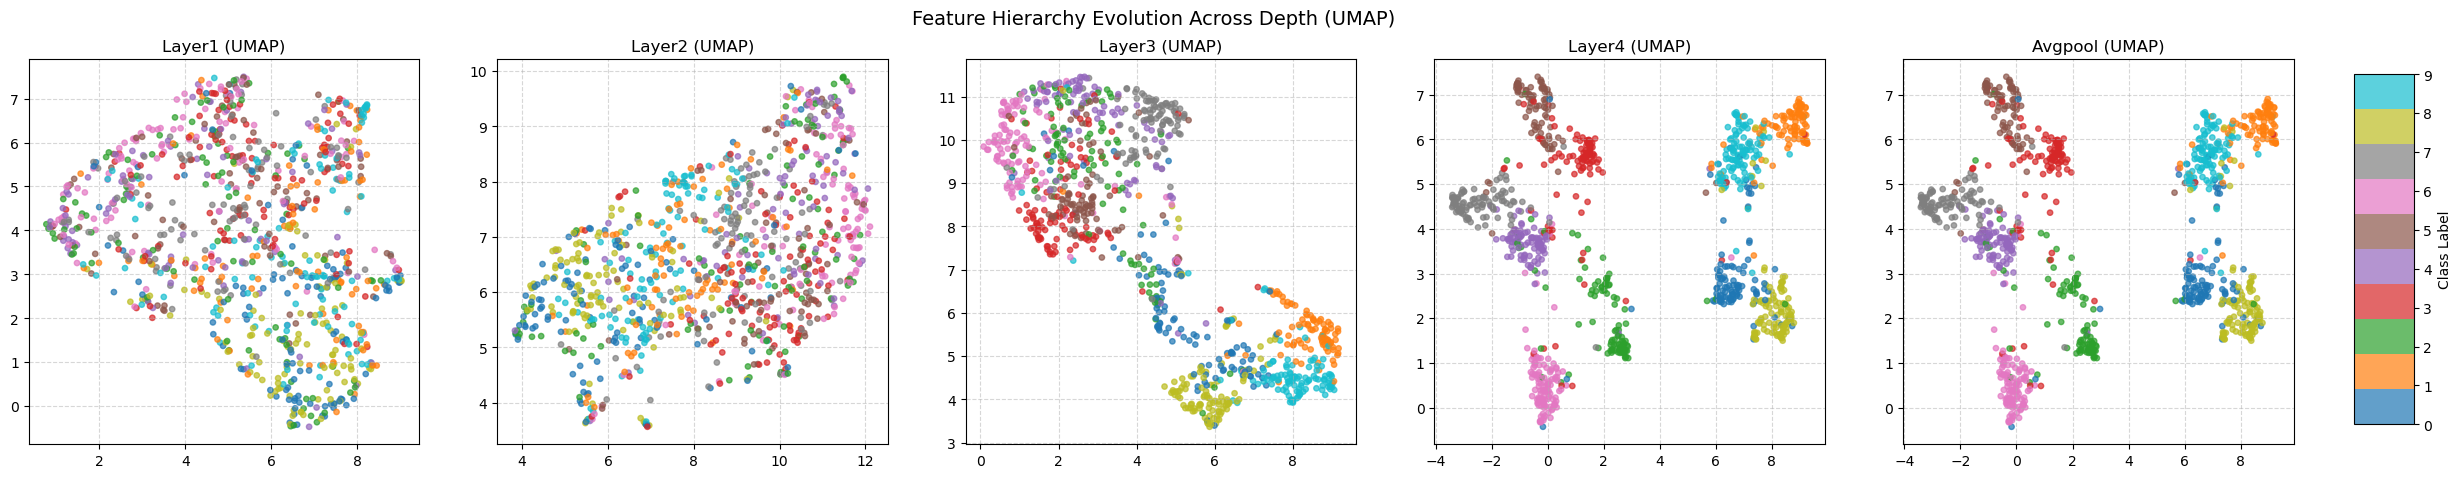

In [3]:
# Multi-Layer t-SNE Grid
plot_multi_layer_projections(
    flat_activations,
    labels_np,
    method='tsne',
    save_path='../results/figures/feature_hierarchy_tsne.png'
)

# Multi-Layer UMAP Grid
plot_multi_layer_projections(
    flat_activations,
    labels_np,
    method='umap',
    save_path='../results/figures/feature_hierarchy_umap.png'
)

### Cross-Layer Representation Similarity Heatmap

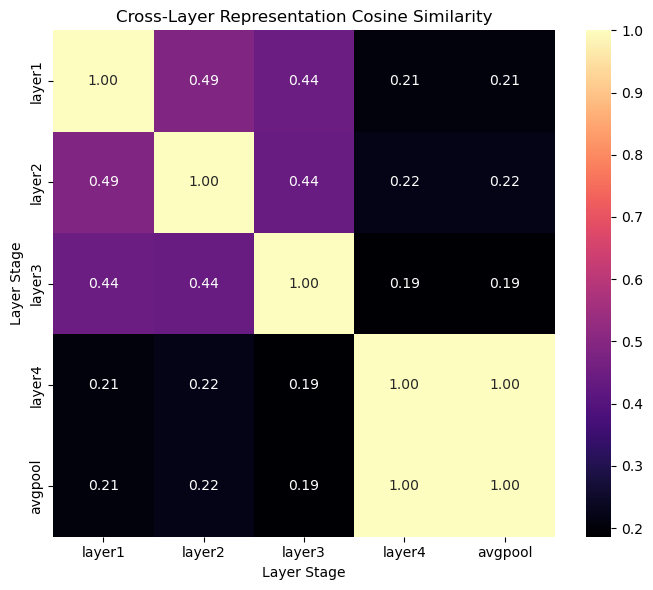

In [4]:
# Cross-Layer Cosine Similarity Matrix
plot_layer_similarity_matrix(
    flat_activations,
    save_path='../results/figures/layer_similarity_matrix.png'
)

### Discussion Questions & Empirical Analysis

**1. How does class separability evolve across layer depth in ResNet-152?**
- **Early Layers (`layer1`, `layer2`):** Extract low-level, generic visual features (edges, oriented contours, texture patterns). Class representations overlap heavily in low-dimensional projections, as early features are shared across distinct object categories.
- **Deep Layers (`layer4`, `avgpool`):** Form highly concentrated, linearly separable clusters corresponding to semantic category boundaries. High-level features become invariant to pose and background variations.

**2. Comparing t-SNE vs. UMAP in Visualizing Deep Feature Manifolds:**
- **t-SNE:** Excellent at revealing local cluster compactness, but distorts global inter-cluster distance relationships.
- **UMAP:** Preserves both local neighborhood structure and global topological relationships between semantic categories.